In [1]:
import pandas as pd

print("Pandas carregado com sucesso!")

Pandas carregado com sucesso!


In [4]:
# Dados econômicos: Ano, Salário Mínimo da época e o Índice de Inflação Acumulado (IPCA)
dados_economicos = {
    'Ano': [1994, 1997, 2000, 2005, 2010, 2015, 2020, 2023, 2024, 2026],
    'Salario_Nominal': [64.79, 120.00, 151.00, 300.00, 510.00, 788.00, 1045.00, 1320.00, 1412.00, 1582.00],
    'Indice_IPCA': [100.0, 134.5, 153.2, 222.8, 291.1, 401.5, 512.4, 610.2, 638.1, 685.4]
}

# Transformando o dicionário em um DataFrame do Pandas
df = pd.DataFrame(dados_economicos)
print("DataFrame criado com sucesso!")
print()

print(df)

DataFrame criado com sucesso!

    Ano  Salario_Nominal  Indice_IPCA
0  1994            64.79        100.0
1  1997           120.00        134.5
2  2000           151.00        153.2
3  2005           300.00        222.8
4  2010           510.00        291.1
5  2015           788.00        401.5
6  2020          1045.00        512.4
7  2023          1320.00        610.2
8  2024          1412.00        638.1
9  2026          1582.00        685.4


In [5]:
# Mostra as linhas da tabela
print("--- VISUALIZAÇÃO DA TABELA ---")
display(df)

print("\n--- INFORMAÇÕES TÉCNICAS ---")
df.info()

--- VISUALIZAÇÃO DA TABELA ---


,Ano,Salario_Nominal,Indice_IPCA
0,1994,64.79,100.0
1,1997,120.00,134.5
2,2000,151.00,153.2
3,2005,300.00,222.8
4,2010,510.00,291.1
5,2015,788.00,401.5
6,2020,1045.00,512.4
7,2023,1320.00,610.2
8,2024,1412.00,638.1
9,2026,1582.00,685.4



--- INFORMAÇÕES TÉCNICAS ---
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ano              10 non-null     int64  
 1   Salario_Nominal  10 non-null     float64
 2   Indice_IPCA      10 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 372.0 bytes


In [6]:
# Pegando o último valor da coluna Indice_IPCA (que corresponde a 2026)
ipca_atual = df['Indice_IPCA'].iloc[-1]
print(f"O nosso índice âncora (IPCA de 2026) é: {ipca_atual}")

O nosso índice âncora (IPCA de 2026) é: 685.4


In [7]:
# Criando a coluna do Salário Corrigido (Poder de Compra Real em valores de 2026)
df['Salario_Real_2026'] = df['Salario_Nominal'] * (ipca_atual / df['Indice_IPCA'])

# Arredondando as casas decimais para duas casas (padrão monetário)
df['Salario_Real_2026'] = df['Salario_Real_2026'].round(2)

# Vendo o resultado final da nossa análise
df

,Ano,Salario_Nominal,Indice_IPCA,Salario_Real_2026
0,1994,64.79,100.0,444.07
1,1997,120.00,134.5,611.51
2,2000,151.00,153.2,675.56
3,2005,300.00,222.8,922.89
4,2010,510.00,291.1,1200.80
5,2015,788.00,401.5,1345.19
6,2020,1045.00,512.4,1397.82
7,2023,1320.00,610.2,1482.67
8,2024,1412.00,638.1,1516.67
9,2026,1582.00,685.4,1582.00


In [8]:
# Ordenando do maior salário real para o menor
tabela_ranking = df.sort_values(by='Salario_Real_2026', ascending=False)

print("RANKING DO PODER DE COMPRA REAL (Valores corrigidos para 2026):")
tabela_ranking

RANKING DO PODER DE COMPRA REAL (Valores corrigidos para 2026):


,Ano,Salario_Nominal,Indice_IPCA,Salario_Real_2026
9,2026,1582.00,685.4,1582.00
8,2024,1412.00,638.1,1516.67
7,2023,1320.00,610.2,1482.67
6,2020,1045.00,512.4,1397.82
5,2015,788.00,401.5,1345.19
4,2010,510.00,291.1,1200.80
3,2005,300.00,222.8,922.89
2,2000,151.00,153.2,675.56
1,1997,120.00,134.5,611.51
0,1994,64.79,100.0,444.07


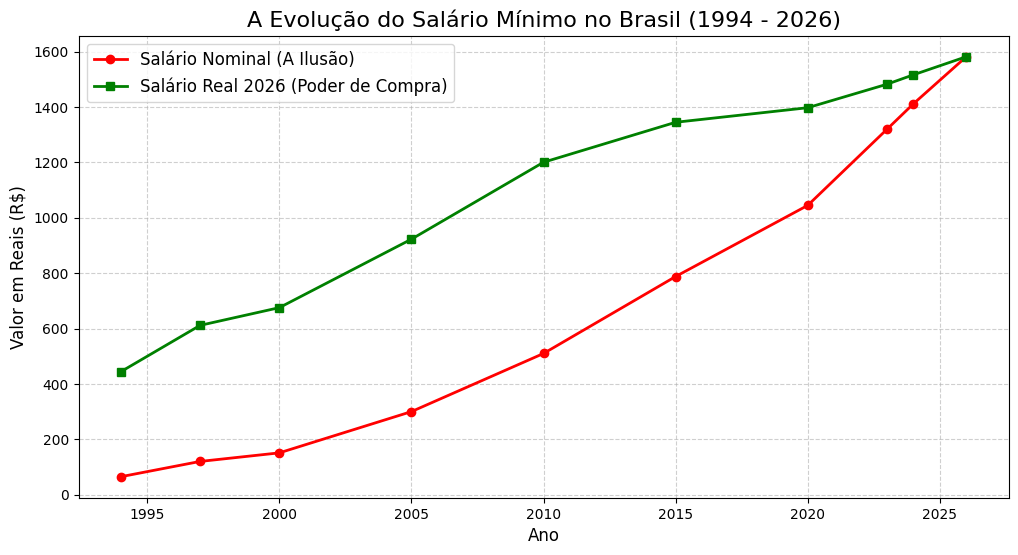

In [10]:
# Importando a biblioteca de gráficos
import matplotlib.pyplot as plt

# 1. Preparando a "tela" do gráfico
plt.figure(figsize=(12, 6))

# 2. Desenhando a Linha do Salário Nominal (Em Vermelho)
plt.plot(df['Ano'], df['Salario_Nominal'], label='Salário Nominal (A Ilusão)', 
         color='red', marker='o', linewidth=2)

# 3. Desenhando a Linha do Salário Real Corrigido (Em Verde)
plt.plot(df['Ano'], df['Salario_Real_2026'], label='Salário Real 2026 (Poder de Compra)', 
         color='green', marker='s', linewidth=2)

# 4. Adicionando os textos, rótulos e legendas
plt.title('A Evolução do Salário Mínimo no Brasil (1994 - 2026)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Valor em Reais (R$)', fontsize=12)
plt.legend(fontsize=12)

# 5. Adicionando uma grade de fundo para facilitar a leitura matemática
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Comando final para exibir a imagem na tela
plt.show()

In [11]:
crescimento_nominal = ((df['Salario_Nominal'].iloc[-1] - df['Salario_Nominal'].iloc[0]) / df['Salario_Nominal'].iloc[0]) * 100
print(f"O salário nominal subiu assustadores: {crescimento_nominal:.2f}%")


O salário nominal subiu assustadores: 2341.73%


In [12]:
crescimento_real = ((df['Salario_Real_2026'].iloc[-1] - df['Salario_Real_2026'].iloc[0]) / df['Salario_Real_2026'].iloc[0]) * 100
print(f"O ganho real de poder de compra de verdade foi de apenas: {crescimento_real:.2f}%")


O ganho real de poder de compra de verdade foi de apenas: 256.25%


In [13]:
linha_melhor_ano = df.loc[df['Salario_Real_2026'].idxmax()]
print(f"O melhor poder de compra da história recente foi em {int(linha_melhor_ano['Ano'])} valendo o equivalente a R$ {linha_melhor_ano['Salario_Real_2026']} de hoje.")

O melhor poder de compra da história recente foi em 2026 valendo o equivalente a R$ 1582.0 de hoje.


In [14]:
linha_pior_ano = df.loc[df['Salario_Real_2026'].idxmin()]
print(f"O pior poder de compra foi em {int(linha_pior_ano['Ano'])} valendo o equivalente a R$ {linha_pior_ano['Salario_Real_2026']} de hoje.")

O pior poder de compra foi em 1994 valendo o equivalente a R$ 444.07 de hoje.


In [15]:
df_seculo_21 = df[df['Ano'] >= 2000]
print("Dados filtrados para o Século XXI:")
display(df_seculo_21)

Dados filtrados para o Século XXI:


,Ano,Salario_Nominal,Indice_IPCA,Salario_Real_2026
2,2000,151.0,153.2,675.56
3,2005,300.0,222.8,922.89
4,2010,510.0,291.1,1200.80
5,2015,788.0,401.5,1345.19
6,2020,1045.0,512.4,1397.82
7,2023,1320.0,610.2,1482.67
8,2024,1412.0,638.1,1516.67
9,2026,1582.0,685.4,1582.00


In [16]:
df['Variacao_em_Reais'] = df['Salario_Real_2026'].diff().round(2)
display(df)

,Ano,Salario_Nominal,Indice_IPCA,Salario_Real_2026,Variacao_em_Reais
0,1994,64.79,100.0,444.07,NaN
1,1997,120.00,134.5,611.51,167.44
2,2000,151.00,153.2,675.56,64.05
3,2005,300.00,222.8,922.89,247.33
4,2010,510.00,291.1,1200.80,277.91
5,2015,788.00,401.5,1345.19,144.39
6,2020,1045.00,512.4,1397.82,52.63
7,2023,1320.00,610.2,1482.67,84.85
8,2024,1412.00,638.1,1516.67,34.00
9,2026,1582.00,685.4,1582.00,65.33


In [17]:
resumo_estatistico = df['Salario_Real_2026'].describe().round(2)
display(resumo_estatistico)


count      10.00
mean     1117.92
std       420.12
min       444.07
25%       737.39
50%      1272.99
75%      1461.46
max      1582.00
Name: Salario_Real_2026, dtype: float64

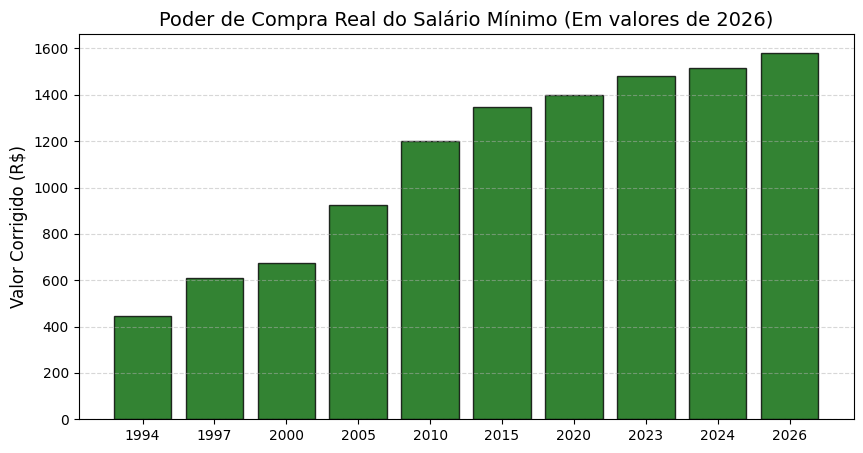

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(df['Ano'].astype(str), df['Salario_Real_2026'], color='darkgreen', alpha=0.8, edgecolor='black')
plt.title('Poder de Compra Real do Salário Mínimo (Em valores de 2026)', fontsize=14)
plt.ylabel('Valor Corrigido (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [19]:
df.to_excel('Relatorio_Salario_Minimo_DIEESE.xlsx', index=False)
print("Sucesso! Arquivo 'Relatorio_Salario_Minimo_DIEESE.xlsx' gerado na pasta do seu projeto.")

Sucesso! Arquivo 'Relatorio_Salario_Minimo_DIEESE.xlsx' gerado na pasta do seu projeto.


In [20]:
df_verificacao = pd.read_excel('Relatorio_Salario_Minimo_DIEESE.xlsx')
print("Auditoria concluída. Primeiras linhas do arquivo Excel salvo:")
display(df_verificacao.head())

Auditoria concluída. Primeiras linhas do arquivo Excel salvo:


,Ano,Salario_Nominal,Indice_IPCA,Salario_Real_2026,Variacao_em_Reais
0,1994,64.79,100.0,444.07,NaN
1,1997,120.00,134.5,611.51,167.44
2,2000,151.00,153.2,675.56,64.05
3,2005,300.00,222.8,922.89,247.33
4,2010,510.00,291.1,1200.80,277.91
